# ACES to sRGB Conversion & Image Degradation Exploration

This notebook explores the synthesis of training data for LuminaScale by:
1. Converting ACES2065-1 EXR images to sRGB using OpenImageIO
2. Applying synthetic degradations to simulate 8-bit AI-generated images
3. Visualizing the effects of quantization, color warping, and artifacts

In [ ]:
import os
import sys
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add src to path for imports
sys.path.insert(0, str(Path("..").resolve() / "src"))

from luminascale.utils.look_generator import CDLParameters, get_single_random_look
from luminascale.utils.io import oiio_aces_to_display, oiio_aces_to_srgb_with_look

In [2]:
# Set random seed for reproducibility
random.seed(42)

# Pick 9 random images from the ACES dataset
aces_dir = Path("../dataset/temp/aces")
all_aces_files = sorted(glob.glob(str(aces_dir / "*.exr")))
print(f"Total ACES images available: {len(all_aces_files)}")

selected_images = random.sample(all_aces_files, min(9, len(all_aces_files)))
print(f"\nSelected {len(selected_images)} random images:")
for img in selected_images:
    print(f"  {Path(img).name}")

Total ACES images available: 880

Selected 9 random images:
  1105_9.exr
  1018_2.exr
  1004_0.exr
  1123_2.exr
  1049_1.exr
  1041_3.exr
  1036_3.exr
  1020_8.exr
  1122_4.exr


In [3]:
# Load and convert ACES images to display-referred using ociodisplay
converted_images = []

for idx, img_path in enumerate(selected_images):
    print(f"[{idx+1}/{len(selected_images)}] {Path(img_path).name}...", end=" ")
    
    # Convert ACES → display-referred using ociodisplay (RRT + ODT)
    pixels = oiio_aces_to_display(img_path, input_cs="ACES2065-1")
    
    # Ensure RGB format for display (drop alpha if present)
    if pixels.shape[2] == 4:
        pixels = pixels[:, :, :3]
    
    converted_images.append(pixels)
    print("✓")

print(f"\nConverted {len(converted_images)} images")

[1/9] 1105_9.exr... ✓
[2/9] 1018_2.exr... ✓
[3/9] 1004_0.exr... ✓
[4/9] 1123_2.exr... ✓
[5/9] 1049_1.exr... ✓
[6/9] 1041_3.exr... ✓
[7/9] 1036_3.exr... ✓
[8/9] 1020_8.exr... ✓
[9/9] 1122_4.exr... ✓

Converted 9 images


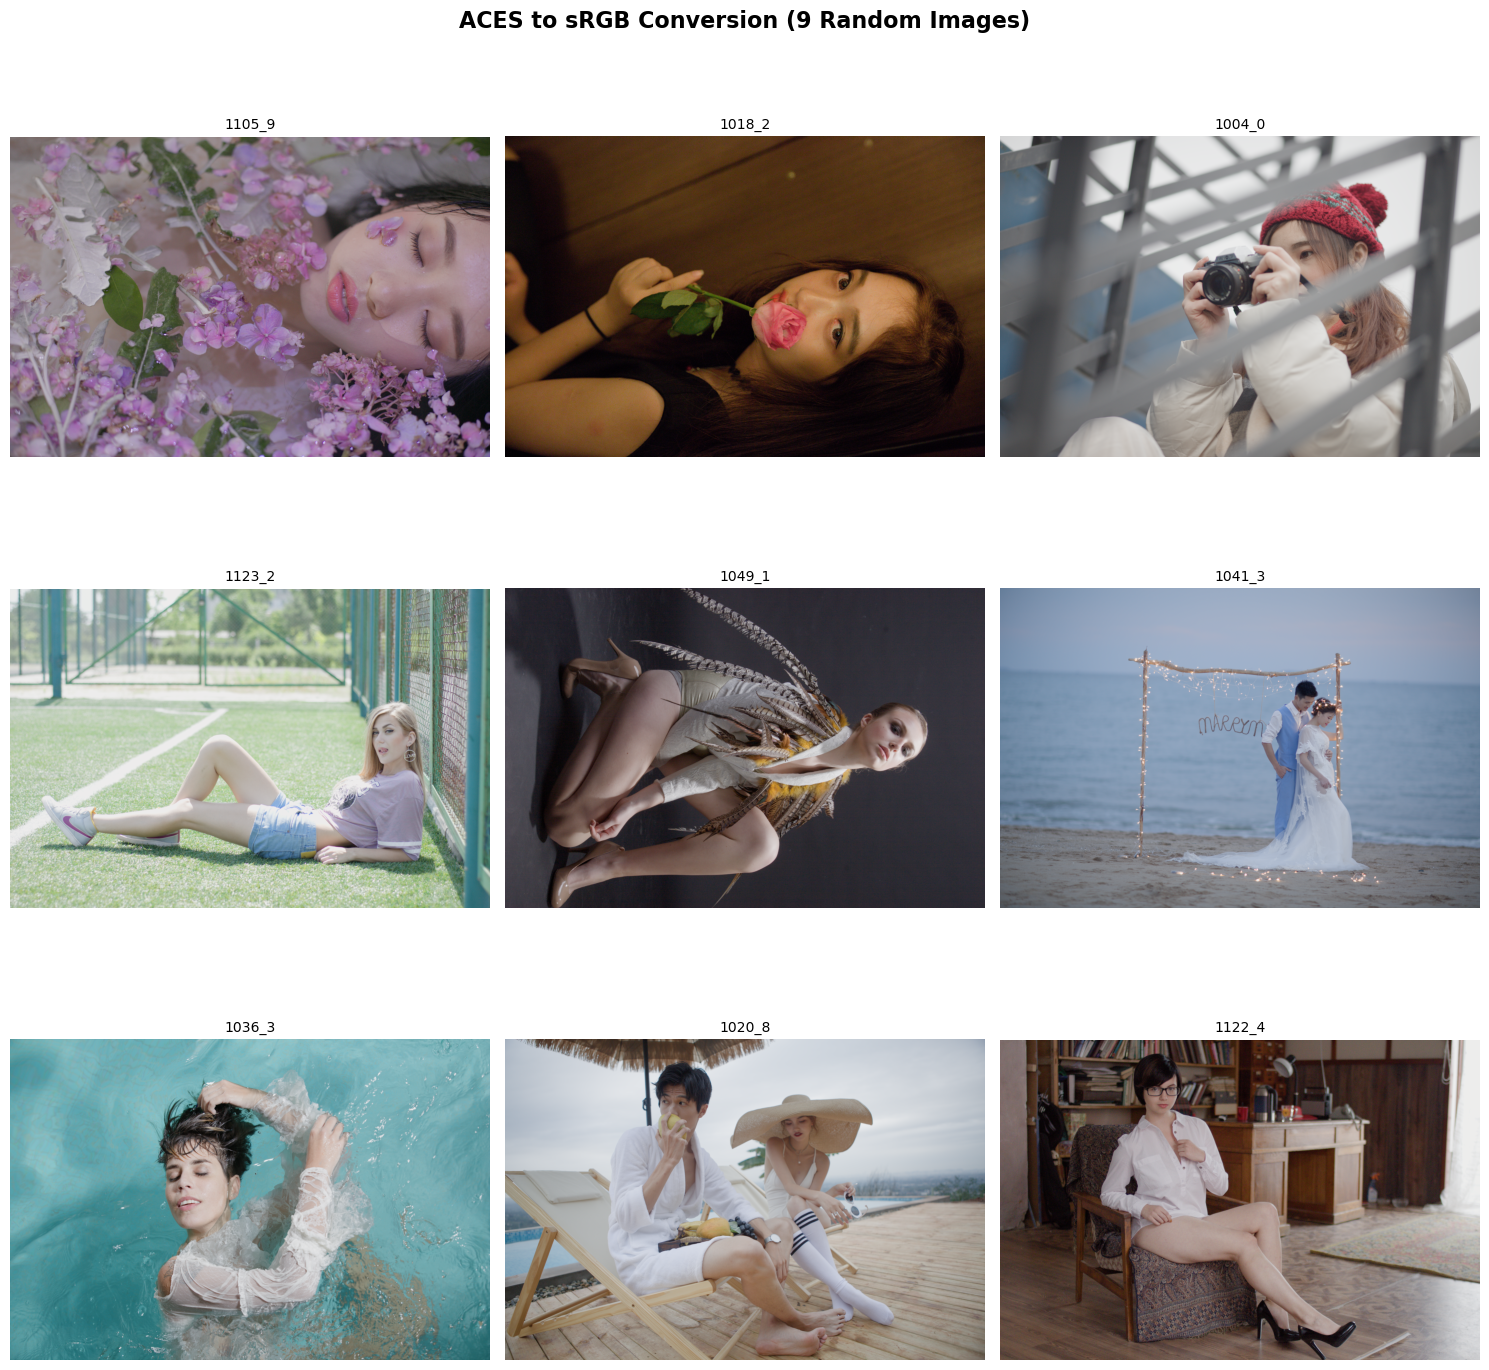

In [4]:
# Display in 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle("ACES to sRGB Conversion (9 Random Images)", fontsize=16, fontweight="bold")

for idx, (ax, img) in enumerate(zip(axes.flat, converted_images)):
    ax.imshow(img)
    img_name = Path(selected_images[idx]).stem
    ax.set_title(f"{img_name}", fontsize=10)
    ax.axis("off")

# Hide remaining subplots if fewer than 9 images
for idx in range(len(converted_images), 9):
    axes.flat[idx].axis("off")

plt.tight_layout()
plt.show()

[1/9] 1105_9.exr... ✓
[2/9] 1018_2.exr... ✓
[3/9] 1004_0.exr... ✓
[4/9] 1123_2.exr... ✓
[5/9] 1049_1.exr... ✓
[6/9] 1041_3.exr... ✓
[7/9] 1036_3.exr... ✓
[8/9] 1020_8.exr... ✓
[9/9] 1122_4.exr... ✓

Generated 9 images with unique random looks


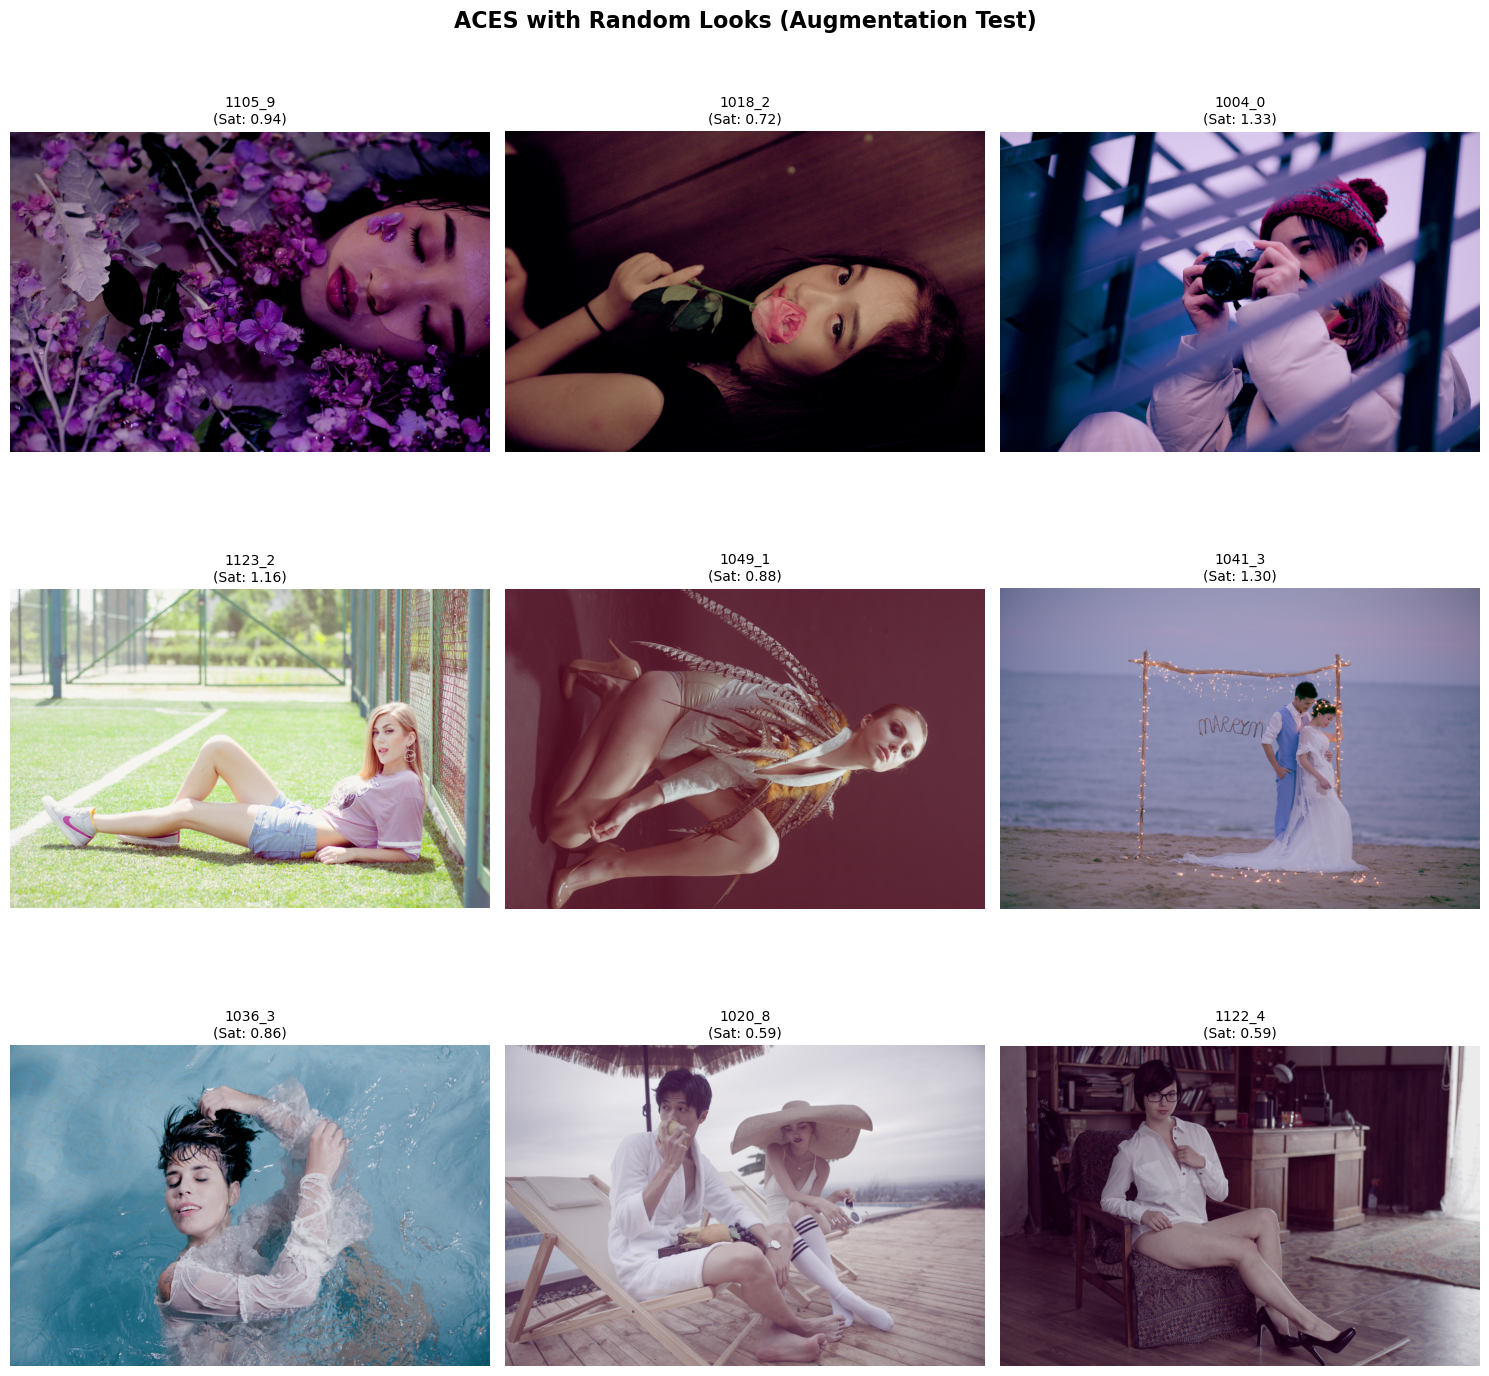

In [ ]:
from luminascale.utils.look_generator import get_single_random_look
from luminascale.utils.io import oiio_aces_to_srgb_with_look

# Load and convert ACES images with RANDOM LOOKS
converted_images = []
applied_looks = []  # Optional: keep track of what parameters were used

for idx, img_path in enumerate(selected_images):
    print(f"[{idx+1}/{len(selected_images)}] {Path(img_path).name}...", end=" ")

    # 1. Generate a unique random look for THIS specific image
    random_look = get_single_random_look()

    # 2. Convert ACES → Graded → display-referred
    # This uses the 'one-in, one-out' logic we built
    pixels = oiio_aces_to_srgb_with_look(img_path, random_look)

    # Ensure RGB format (drop alpha if present)
    if pixels.shape[2] == 4:
        pixels = pixels[:, :, :3]

    converted_images.append(pixels)
    applied_looks.append(random_look)
    print("✓")

print(f"\nGenerated {len(converted_images)} images with unique random looks")

# Display in 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle(
    "ACES with Random Looks (Augmentation Test)", fontsize=16, fontweight="bold"
)

for idx, (ax, img) in enumerate(zip(axes.flat, converted_images)):
    # Use np.clip to ensure values are in [0, 1] for matplotlib
    ax.imshow(np.clip(img, 0, 1))

    img_name = Path(selected_images[idx]).stem
    # Display the saturation or some parameter in the title to see the variety
    look_info = f"Sat: {applied_looks[idx].saturation:.2f}"
    ax.set_title(f"{img_name}\n({look_info})", fontsize=10)
    ax.axis("off")

# Hide remaining subplots
for idx in range(len(converted_images), 9):
    axes.flat[idx].axis("off")

plt.tight_layout()
plt.show()

[1/9] 1105_9.exr... ✓ (polaroid_690)
[2/9] 1018_2.exr... ✓ (kodak_elite_chrome_400)
[3/9] 1004_0.exr... ✓ (agfa_precisa_100)
[4/9] 1123_2.exr... ✓ (kodak_kodachrome_25)
[5/9] 1049_1.exr... ✓ (fuji_velvia_100_generic)
[6/9] 1041_3.exr... ✓ (kodak_elite_chrome_200)
[7/9] 1036_3.exr... ✓ (agfa_precisa_100)
[8/9] 1020_8.exr... ✓ (fuji_fp_100c)
[9/9] 1122_4.exr... ✓ (fuji_velvia_50)

Generated 9 images with random film simulations


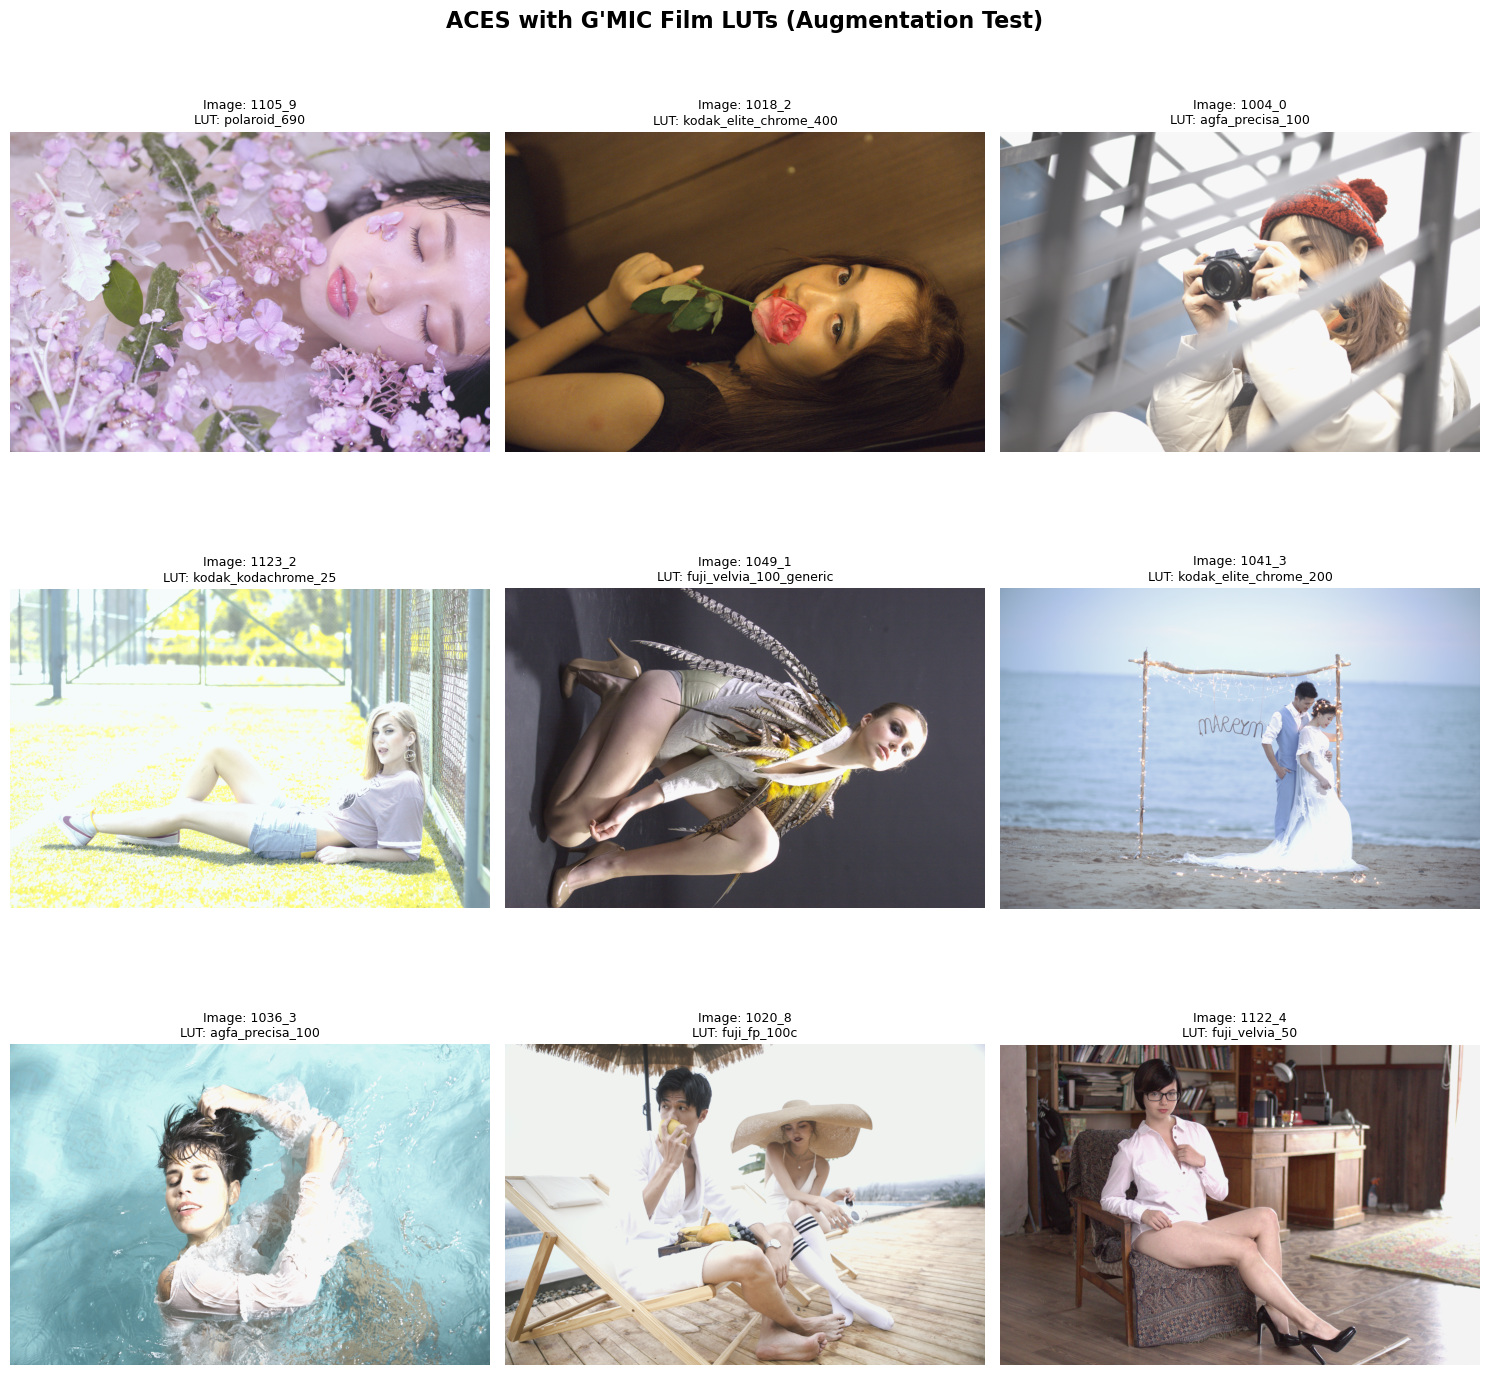

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from luminascale.utils.look_generator import LUTManager
from luminascale.utils.io import apply_lut_to_image

# 1. Initialize the LUT Manager with your specific path
lut_dir = "/mnt/Projects/Projects/med8_project/LuminaScale/dataset/gmic_film_luts/luts"
lut_mgr = LUTManager(lut_dir)

# Load and convert ACES images with RANDOM FILM LUTs
converted_images = []
applied_lut_names = []

for idx, img_path in enumerate(selected_images):
    print(f"[{idx+1}/{len(selected_images)}] {Path(img_path).name}...", end=" ")

    # 2. Pick a random LUT file from your G'MIC collection
    random_lut_path = lut_mgr.get_random_lut()

    if random_lut_path:
        # 3. Convert ACES → Apply .cube → display-referred
        pixels = apply_lut_to_image(img_path, random_lut_path)

        # Ensure RGB format (drop alpha if present)
        if pixels.shape[2] == 4:
            pixels = pixels[:, :, :3]

        converted_images.append(pixels)
        applied_lut_names.append(random_lut_path.stem)
        print(f"✓ ({random_lut_path.stem})")
    else:
        print("✗ No LUTs found in directory!")

print(f"\nGenerated {len(converted_images)} images with random film simulations")

# Display in 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle(
    "ACES with G'MIC Film LUTs (Augmentation Test)", fontsize=16, fontweight="bold"
)

for idx, (ax, img) in enumerate(zip(axes.flat, converted_images)):
    # Standardize display range [0, 1]
    ax.imshow(np.clip(img, 0, 1))

    img_name = Path(selected_images[idx]).stem
    lut_name = applied_lut_names[idx]

    # Show the LUT filename in the title to identify the look
    ax.set_title(f"Image: {img_name}\nLUT: {lut_name}", fontsize=9)
    ax.axis("off")

# Hide remaining subplots
for idx in range(len(converted_images), 9):
    axes.flat[idx].axis("off")

plt.tight_layout()
plt.show()